# UniLumos BSS Official-Protocol Smoke

This notebook is Colab-first. It can clone or update the experiment branch from GitHub, mount Google Drive for weights and outputs, create the one-case smoke manifest, dry-run commands, and optionally run the smoke.

By default it does not run the model. Set `RUN_SMOKE = True` only after the path and weight checks pass.

## 1. Configure Sources And Drive Paths

Edit these values only if you move the fork, branch, weights, or output root.

In [27]:
from pathlib import Path
import os
import sys
import json
import subprocess
import shutil

GITHUB_REPO = "https://github.com/WANG-Ruipeng/Lumos-Custom.git"
BRANCH = "bss-unilumos-official-smoke"
LOCAL_REPO_ROOT = Path("/content/Lumos-Custom")

DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_WEIGHTS_ROOT = DRIVE_ROOT / "Colab_Projects" / "UniLumos" / "weights"
LOCAL_WEIGHTS_ROOT = LOCAL_REPO_ROOT / "UniLumos" / "UniLumos" / "weights"
WEIGHTS_ROOT = LOCAL_WEIGHTS_ROOT
EXP_ROOT = DRIVE_ROOT / "Colab_Projects" / "UniLumos-BSS-Runs" / "model_b_unilumos_official_bss_smoke_v1"

HF_REPO_ID = "Alibaba-DAMO-Academy/UniLumos"
DOWNLOAD_WEIGHTS_TO_DRIVE = False
STAGE_WEIGHTS_TO_LOCAL = True
RUN_INSTALL = True
INSTALL_TORCH_MODE = "auto"  # auto, requirements, or cu128 for RTX PRO 6000 Blackwell
RUN_SMOKE = True
RUN_METRICS = True

print("GITHUB_REPO =", GITHUB_REPO)
print("BRANCH =", BRANCH)
print("LOCAL_REPO_ROOT =", LOCAL_REPO_ROOT)
print("DRIVE_WEIGHTS_ROOT =", DRIVE_WEIGHTS_ROOT)
print("LOCAL_WEIGHTS_ROOT =", LOCAL_WEIGHTS_ROOT)
print("WEIGHTS_ROOT =", WEIGHTS_ROOT)
print("INSTALL_TORCH_MODE =", INSTALL_TORCH_MODE)
print("EXP_ROOT =", EXP_ROOT)

GITHUB_REPO = https://github.com/WANG-Ruipeng/Lumos-Custom.git
BRANCH = bss-unilumos-official-smoke
LOCAL_REPO_ROOT = /content/Lumos-Custom
DRIVE_WEIGHTS_ROOT = /content/drive/MyDrive/Colab_Projects/UniLumos/weights
LOCAL_WEIGHTS_ROOT = /content/Lumos-Custom/UniLumos/UniLumos/weights
WEIGHTS_ROOT = /content/Lumos-Custom/UniLumos/UniLumos/weights
INSTALL_TORCH_MODE = auto
EXP_ROOT = /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1


## 2. Mount Google Drive

Weights and experiment outputs live on Drive. Code is cloned into Colab's local `/content` workspace.

In [2]:
IN_COLAB = Path("/content").exists()
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Not running in Colab; Drive mount skipped.")

print("Drive available:", DRIVE_ROOT.exists())

Mounted at /content/drive
Drive available: True


## 3. Clone Or Pull The Experiment Branch

This cell is safe to rerun. If `/content/Lumos-Custom` already exists, it fetches and fast-forward pulls the configured branch. Otherwise it clones the branch.

In [21]:
def run(cmd, cwd=None, check=True):
    print("$", " ".join(str(x) for x in cmd))
    return subprocess.run(cmd, cwd=cwd, check=check, text=True)

if LOCAL_REPO_ROOT.exists() and (LOCAL_REPO_ROOT / ".git").exists():
    run(["git", "fetch", "origin", BRANCH], cwd=LOCAL_REPO_ROOT)
    run(["git", "checkout", BRANCH], cwd=LOCAL_REPO_ROOT)
    run(["git", "pull", "--ff-only", "origin", BRANCH], cwd=LOCAL_REPO_ROOT)
else:
    LOCAL_REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
    run(["git", "clone", "-b", BRANCH, GITHUB_REPO, str(LOCAL_REPO_ROOT)])

TASK_ROOT = LOCAL_REPO_ROOT / "UniLumos"
CODE_ROOT = TASK_ROOT / "UniLumos"
assert (CODE_ROOT / "unilumos_infer_abc.py").exists(), CODE_ROOT

os.environ["PYTHONPATH"] = f"{TASK_ROOT}:{CODE_ROOT}:" + os.environ.get("PYTHONPATH", "")
if str(TASK_ROOT) not in sys.path:
    sys.path.insert(0, str(TASK_ROOT))
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=LOCAL_REPO_ROOT, text=True).strip()
print("TASK_ROOT =", TASK_ROOT)
print("CODE_ROOT =", CODE_ROOT)
print("Checked out commit =", commit)

$ git fetch origin bss-unilumos-official-smoke
$ git checkout bss-unilumos-official-smoke
$ git pull --ff-only origin bss-unilumos-official-smoke
TASK_ROOT = /content/Lumos-Custom/UniLumos
CODE_ROOT = /content/Lumos-Custom/UniLumos/UniLumos
Checked out commit = 2438915


## 4. Optional Dependency Install

Set `RUN_INSTALL = True` in the first cell if this Colab runtime does not already have UniLumos dependencies. `INSTALL_TORCH_MODE = "auto"` keeps the official requirements path on normal GPUs and switches to PyTorch CUDA 12.8 wheels on RTX PRO 6000 / Blackwell.

In [15]:
if RUN_INSTALL:
    install_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "install_colab_unilumos_deps.py"),
        "--torch-mode", INSTALL_TORCH_MODE,
    ]
    subprocess.check_call(install_cmd)
else:
    print("Dependency install skipped. Set RUN_INSTALL = True if needed.")

## 5. Optional One-Time Weight Download To Drive

Use this once per Drive setup. The UniLumos Hugging Face repository is gated, so first accept the model terms in the browser, then set `DOWNLOAD_WEIGHTS_TO_DRIVE = True` and run this cell. It downloads the repository files into `DRIVE_WEIGHTS_ROOT`.

In [5]:
if DOWNLOAD_WEIGHTS_TO_DRIVE:
    DRIVE_WEIGHTS_ROOT.mkdir(parents=True, exist_ok=True)
    run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import notebook_login, snapshot_download

    notebook_login()
    snapshot_download(
        repo_id=HF_REPO_ID,
        local_dir=str(DRIVE_WEIGHTS_ROOT),
        local_dir_use_symlinks=False,
    )
    print("Downloaded weights to Drive:", DRIVE_WEIGHTS_ROOT)
else:
    print("DOWNLOAD_WEIGHTS_TO_DRIVE is False; one-time HF download skipped.")


DOWNLOAD_WEIGHTS_TO_DRIVE is False; one-time HF download skipped.


## 6. Stage Weights To Local Runtime

Every fresh Colab runtime should stage weights from Drive to local disk before smoke execution. This mirrors the Relit-LiVE notebook pattern: Drive is persistent storage, local `/content` is the fast read path.

In [6]:
def sync_tree(src: Path, dst: Path) -> None:
    if not src.exists():
        raise FileNotFoundError(f"Source does not exist: {src}")
    dst.mkdir(parents=True, exist_ok=True)
    if shutil.which("rsync"):
        run(["rsync", "-a", "--info=progress2", str(src) + "/", str(dst) + "/"])
    else:
        shutil.copytree(src, dst, dirs_exist_ok=True)

if STAGE_WEIGHTS_TO_LOCAL:
    sync_tree(DRIVE_WEIGHTS_ROOT, LOCAL_WEIGHTS_ROOT)
    WEIGHTS_ROOT = LOCAL_WEIGHTS_ROOT
else:
    WEIGHTS_ROOT = DRIVE_WEIGHTS_ROOT

print("Using WEIGHTS_ROOT:", WEIGHTS_ROOT)


$ rsync -a --info=progress2 /content/drive/MyDrive/Colab_Projects/UniLumos/weights/ /content/Lumos-Custom/UniLumos/UniLumos/weights/
Using WEIGHTS_ROOT: /content/Lumos-Custom/UniLumos/UniLumos/weights


## 7. Verify Code, Examples, And Weights

The local repository contains examples. The large model files should be on Drive under `WEIGHTS_ROOT`.

In [19]:
required_code = [
    TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "make_manifest_unilumos_official_smoke.py",
    TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "run_manifest.py",
    CODE_ROOT / "examples" / "examples_refined.csv",
    CODE_ROOT / "unilumos_infer_abc.py",
    CODE_ROOT / "src" / "schedulers" / "RFLOW_WANX21_T2V.py",
]
required_weights = [
    WEIGHTS_ROOT / "models_t5_umt5-xxl-enc-bf16.pth",
    WEIGHTS_ROOT / "umt5-xxl",
    WEIGHTS_ROOT / "vae.pth",
    WEIGHTS_ROOT / "unilumos.pt",
]

missing = []
for path in required_code + required_weights:
    ok = path.exists()
    print(("OK      " if ok else "MISSING "), path)
    if not ok:
        missing.append(str(path))

if missing:
    print()
    print("Missing items detected. You can still run manifest dry-run, but do not set RUN_SMOKE=True until weights exist.")


OK       /content/Lumos-Custom/UniLumos/bss_experiments/unilumos/scripts/make_manifest_unilumos_official_smoke.py
OK       /content/Lumos-Custom/UniLumos/bss_experiments/unilumos/scripts/run_manifest.py
OK       /content/Lumos-Custom/UniLumos/UniLumos/examples/examples_refined.csv
OK       /content/Lumos-Custom/UniLumos/UniLumos/unilumos_infer_abc.py
OK       /content/Lumos-Custom/UniLumos/UniLumos/src/schedulers/RFLOW_WANX21_T2V.py
OK       /content/Lumos-Custom/UniLumos/UniLumos/weights/models_t5_umt5-xxl-enc-bf16.pth
OK       /content/Lumos-Custom/UniLumos/UniLumos/weights/umt5-xxl
OK       /content/Lumos-Custom/UniLumos/UniLumos/weights/vae.pth
OK       /content/Lumos-Custom/UniLumos/UniLumos/weights/unilumos.pt


## 8. Validate BSS Schedule Logic Locally

This is lightweight and does not load UniLumos weights.

In [8]:
from bss_experiments.unilumos.bss_core.grids import get_uniform_shifted_sigmas, make_boundary_split_coords
from bss_experiments.unilumos.bss_core.validate import validate_schedule_payload

base8 = get_uniform_shifted_sigmas(8, 8.0)
bss10, meta = make_boundary_split_coords(base8)
payload = {
    "model_name": "UniLumos",
    "method": "bss10",
    "sampler_mode": "bss",
    "sample_steps": 10,
    "sample_shift": 8.0,
    "base_sample_steps": 8,
    "actual_nfe": 10,
    "split_pairs": "0,-1",
    "terminal_coord": 0.0,
    "base_sigmas": base8,
    "final_sigmas": bss10,
    "timesteps": list(range(10)),
}
result = validate_schedule_payload(payload, raise_on_error=True)
print(json.dumps(result, indent=2))

{
  "ok": true,
  "checks": [
    {
      "name": "model_name",
      "passed": true,
      "detail": "UniLumos"
    },
    {
      "name": "final_sigmas_count",
      "passed": true,
      "detail": "10 vs 10"
    },
    {
      "name": "timesteps_count",
      "passed": true,
      "detail": "10 vs 10"
    },
    {
      "name": "model_eval_count",
      "passed": true,
      "detail": "10 model eval coords"
    },
    {
      "name": "monotone_nonincreasing",
      "passed": true,
      "detail": "[1.0, 0.9912280701754386, 0.9824561403508771, 0.96, 0.9302325581395349, 0.8888888888888888, 0.8275862068965517, 0.7272727272727273, 0.5333333333333333, 0.26666666666666666]"
    },
    {
      "name": "terminal_recorded",
      "passed": true,
      "detail": "0.0"
    },
    {
      "name": "bss_nfe",
      "passed": true,
      "detail": "10 vs 10"
    },
    {
      "name": "bss_base_nfe",
      "passed": true,
      "detail": "8 vs 8"
    },
    {
      "name": "bss_base_plus_midpoints

## 9. Create One-Case Smoke Manifest

The manifest uses the first official `abc` example and creates four rows: `uniform8`, `uniform10`, `bss10`, and `reference_uniform25`.

In [9]:
manifest_cmd = [
    sys.executable,
    str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "make_manifest_unilumos_official_smoke.py"),
    "--experiment_root", str(EXP_ROOT),
    "--max_cases", "1",
    "--mode", "abc",
]
manifest_path = subprocess.check_output(manifest_cmd, text=True).strip()
print("manifest_path =", manifest_path)

manifest_path = /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/manifests/unilumos_official_smoke_manifest.csv


## 10. Dry-Run Commands

This writes `reports/01_dry_run_commands.md` under `EXP_ROOT` and prints the exact commands. It does not run the model.

In [10]:
dry_run_cmd = [
    sys.executable,
    str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "run_manifest.py"),
    "--manifest", manifest_path,
    "--weights_root", str(WEIGHTS_ROOT),
    "--dry_run",
]
subprocess.check_call(dry_run_cmd)
print("Dry-run report:", EXP_ROOT / "reports" / "01_dry_run_commands.md")

Dry-run report: /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/reports/01_dry_run_commands.md


## 11. Run One-Case Smoke

Set `RUN_SMOKE = True` in the first cell only after the weight check passes. This runs exactly four rows.

In [22]:
def print_tail(path: Path, max_lines: int = 100) -> None:
    path = Path(path)
    print(f"\n--- {path} ---")
    if not path.exists():
        print("missing")
        return
    text = path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()
    if not lines:
        print("empty")
        return
    print("\n".join(lines[-max_lines:]))


def show_smoke_context() -> None:
    import csv

    manifest = Path(manifest_path)
    print("\nManifest:", manifest)
    if not manifest.exists():
        print("manifest missing")
        return
    with manifest.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    for row in rows:
        print(row.get("method"), row.get("status"), row.get("error_message"))
    failed = [row for row in rows if row.get("status") == "failed" or row.get("error_message")]
    targets = failed or rows[:1]
    for row in targets[:1]:
        print_tail(row["stderr_log_path"], max_lines=140)
        print_tail(row["stdout_log_path"], max_lines=80)
        runtime_path = Path(row["runtime_json_path"])
        if runtime_path.exists():
            print_tail(runtime_path, max_lines=40)


if RUN_SMOKE:
    run_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "run_manifest.py"),
        "--manifest", manifest_path,
        "--weights_root", str(WEIGHTS_ROOT),
        "--resume",
    ]
    try:
        subprocess.check_call(run_cmd)
    except subprocess.CalledProcessError:
        show_smoke_context()
        raise
else:
    print("RUN_SMOKE is False; model execution skipped.")

## 12. Validate Dumped Schedules

Run after the smoke has produced schedule JSON files.

In [23]:
schedule_paths = sorted((EXP_ROOT / "schedules").glob("*_schedule.json"))
print("schedule json count:", len(schedule_paths))
if schedule_paths:
    validate_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "validate_schedules.py"),
        *map(str, schedule_paths),
    ]
    subprocess.check_call(validate_cmd)
else:
    print("No schedules found yet.")

schedule json count: 4


## 13. Metrics, Table, And Side-By-Side

Set `RUN_METRICS = True` after the four smoke outputs exist.

In [ ]:
if RUN_METRICS:
    metrics_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "compute_metrics_against_ref.py"),
        "--manifest", manifest_path,
    ]
    metrics_csv = subprocess.check_output(metrics_cmd, text=True).strip()
    print("metrics_csv =", metrics_csv)

    table_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "make_main_table.py"),
        "--metrics_csv", metrics_csv,
    ]
    table_md = subprocess.check_output(table_cmd, text=True).strip()
    print("table_md =", table_md)

    side_by_side_cmd = [
        sys.executable,
        str(TASK_ROOT / "bss_experiments" / "unilumos" / "scripts" / "make_side_by_side.py"),
        "--manifest", manifest_path,
    ]
    side_by_side_image = subprocess.check_output(side_by_side_cmd, text=True).strip()
    print("side_by_side_image =", side_by_side_image)
else:
    print("RUN_METRICS is False; metrics/table/side-by-side skipped.")

## 14. Print Smoke Results

Run this after section 13. It prints the effect table, runtime speedups, BSS-vs-uniform10 deltas, and the side-by-side preview path/image.

Manifest: /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/manifests/unilumos_official_smoke_manifest.csv
Metrics CSV: /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/metrics/metrics_against_ref.csv True
Main table: /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/tables/main_smoke_table.md True
Side by side: /content/drive/MyDrive/Colab_Projects/UniLumos-BSS-Runs/model_b_unilumos_official_bss_smoke_v1/figures/side_by_side/one_case_side_by_side.jpg True


**Run Status**

| Method | Status | NFE | Output |
|---|---|---|---|
| uniform8 | done | 8 | example_0_bg_video_1_gen.mp4 |
| uniform10 | done | 10 | example_0_bg_video_1_gen.mp4 |
| bss10 | done | 10 | example_0_bg_video_1_gen.mp4 |
| reference_uniform25 | done | 25 | example_0_bg_video_1_gen.mp4 |

**Effect Table From Section 13**

| Method | NFE | RGB L1 low | RGB L2 low | PSNR high | Temporal ref-error low | RGB closure high | Temporal closure high | BSS win vs uniform10 |
|---|---:|---:|---:|---:|---:|---:|---:|---|
| uniform8 | 8 | 0.0089394 | 0.000219012 | 36.5953 | 0.00614962 | 0 | 0 |  |
| uniform10 | 10 | 0.00791464 | 0.000165213 | 37.8196 | 0.00594484 | 0.114634 | 0.0332999 |  |
| bss10 | 10 | 0.00567667 | 7.40947e-05 | 41.3021 | 0.00521189 | 0.364983 | 0.152486 | True |
| reference_uniform25 | 25 | 0 | 0 | inf | 0 | 1 | 1 |  |


**Runtime And Speedup vs reference_uniform25**

| Method | NFE | Runtime | Runtime speedup | NFE speedup |
|---|---|---|---|---|
| uniform8 | 8 | 45.5s | 1.51x | 3.12x |
| uniform10 | 10 | 47.7s | 1.44x | 2.50x |
| bss10 | 10 | 47.9s | 1.43x | 2.50x |
| reference_uniform25 | 25 | 68.5s | 1.00x | 1.00x |

**BSS10 vs Uniform10**

- RGB L1 improvement vs uniform10: +28.28% (positive means lower error)
- Temporal error improvement vs uniform10: +12.33% (positive means lower error)
- PSNR delta vs uniform10: 3.4826 dB
- Runtime ratio bss10/uniform10: 1.00x

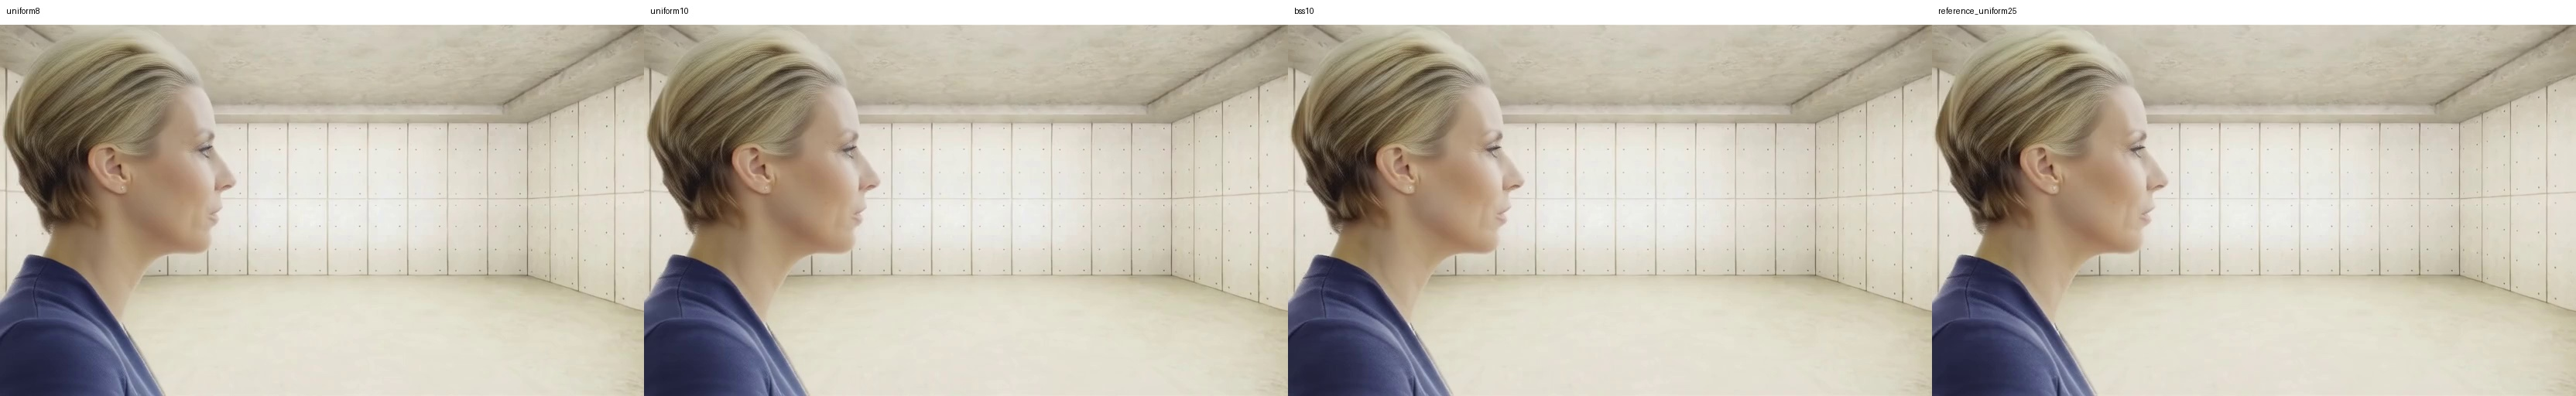

In [29]:
import csv
import json
import math
from pathlib import Path

METHOD_ORDER = ["uniform8", "uniform10", "bss10", "reference_uniform25"]


def existing_output(stem: str) -> Path | None:
    base = Path(stem)
    for suffix in ("", ".mp4", ".png", ".jpg", ".jpeg"):
        candidate = Path(str(base) + suffix)
        if candidate.exists():
            return candidate
    return None


def read_csv_rows(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def as_float(value):
    try:
        return float(value)
    except Exception:
        return None


def fmt_num(value, digits=5):
    number = as_float(value)
    if number is None or not math.isfinite(number):
        return ""
    return f"{number:.{digits}g}"


def fmt_seconds(value):
    number = as_float(value)
    if number is None or not math.isfinite(number):
        return ""
    return f"{number:.1f}s"


def fmt_x(value):
    number = as_float(value)
    if number is None or not math.isfinite(number):
        return ""
    return f"{number:.2f}x"


def fmt_pct(value):
    number = as_float(value)
    if number is None or not math.isfinite(number):
        return ""
    return f"{number:+.2f}%"


def markdown_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(item) for item in row) + " |")
    return "\n".join(lines)


def show_markdown(text: str) -> None:
    try:
        from IPython.display import Markdown, display

        display(Markdown(text))
    except Exception:
        print(text)


summary_manifest = Path(manifest_path) if "manifest_path" in globals() else EXP_ROOT / "manifests" / "unilumos_official_smoke_manifest.csv"
metrics_csv_path = Path(globals().get("metrics_csv", EXP_ROOT / "metrics" / "metrics_against_ref.csv"))
table_md_path = Path(globals().get("table_md", EXP_ROOT / "tables" / "main_smoke_table.md"))
side_by_side_path = Path(globals().get("side_by_side_image", EXP_ROOT / "figures" / "side_by_side" / "one_case_side_by_side.jpg"))

manifest_rows = read_csv_rows(summary_manifest)
metrics_rows = read_csv_rows(metrics_csv_path)

print("Manifest:", summary_manifest)
print("Metrics CSV:", metrics_csv_path, metrics_csv_path.exists())
print("Main table:", table_md_path, table_md_path.exists())
print("Side by side:", side_by_side_path, side_by_side_path.exists())

if not manifest_rows:
    raise FileNotFoundError(f"No manifest rows found: {summary_manifest}")

status_rows = []
for method in METHOD_ORDER:
    row = next((item for item in manifest_rows if item.get("method") == method), None)
    if row:
        output = existing_output(row.get("output_path", ""))
        status_rows.append([method, row.get("status", ""), row.get("actual_nfe", ""), output.name if output else "missing"])
show_markdown("**Run Status**\n\n" + markdown_table(["Method", "Status", "NFE", "Output"], status_rows))

if not metrics_rows:
    print("No metrics rows found. Set RUN_METRICS=True and run section 13 first.")
else:
    if table_md_path.exists():
        show_markdown("**Effect Table From Section 13**\n\n" + table_md_path.read_text(encoding="utf-8"))
    else:
        metrics_by_method = {row.get("method"): row for row in metrics_rows}
        effect_rows = []
        for method in METHOD_ORDER:
            row = metrics_by_method.get(method)
            if row:
                effect_rows.append([
                    method,
                    row.get("actual_nfe", ""),
                    fmt_num(row.get("rgb_l1")),
                    fmt_num(row.get("psnr")),
                    fmt_num(row.get("temporal_diff_l1_to_ref")),
                    fmt_num(row.get("rgb_l1_closure")),
                    fmt_num(row.get("temporal_closure")),
                ])
        show_markdown(
            "**Effect vs reference_uniform25**\n\n"
            + markdown_table(
                ["Method", "NFE", "RGB L1 low", "PSNR high", "Temporal L1 low", "RGB closure high", "Temporal closure high"],
                effect_rows,
            )
        )

runtime_by_method = {}
for row in manifest_rows:
    runtime_path = Path(row.get("runtime_json_path", ""))
    if not runtime_path.exists():
        continue
    data = json.loads(runtime_path.read_text(encoding="utf-8"))
    runtime_by_method[row.get("method")] = as_float(data.get("runtime_seconds"))

manifest_by_method = {row.get("method"): row for row in manifest_rows}
ref_runtime = runtime_by_method.get("reference_uniform25")
ref_nfe = as_float(manifest_by_method.get("reference_uniform25", {}).get("actual_nfe"))
runtime_rows = []
for method in METHOD_ORDER:
    row = manifest_by_method.get(method)
    if not row:
        continue
    seconds = runtime_by_method.get(method)
    nfe = as_float(row.get("actual_nfe"))
    runtime_speedup = ref_runtime / seconds if ref_runtime and seconds else None
    nfe_speedup = ref_nfe / nfe if ref_nfe and nfe else None
    runtime_rows.append([method, row.get("actual_nfe", ""), fmt_seconds(seconds), fmt_x(runtime_speedup), fmt_x(nfe_speedup)])
show_markdown(
    "**Runtime And Speedup vs reference_uniform25**\n\n"
    + markdown_table(["Method", "NFE", "Runtime", "Runtime speedup", "NFE speedup"], runtime_rows)
)

metrics_by_method = {row.get("method"): row for row in metrics_rows}
uniform10 = metrics_by_method.get("uniform10")
bss10 = metrics_by_method.get("bss10")
if uniform10 and bss10:
    def lower_better_delta(metric):
        base = as_float(uniform10.get(metric))
        value = as_float(bss10.get(metric))
        if base is None or value is None or base == 0:
            return None
        return 100.0 * (base - value) / base

    psnr_u10 = as_float(uniform10.get("psnr"))
    psnr_bss = as_float(bss10.get("psnr"))
    runtime_u10 = runtime_by_method.get("uniform10")
    runtime_bss = runtime_by_method.get("bss10")
    bss_vs_uniform_lines = [
        f"- RGB L1 improvement vs uniform10: {fmt_pct(lower_better_delta('rgb_l1'))} (positive means lower error)",
        f"- Temporal error improvement vs uniform10: {fmt_pct(lower_better_delta('temporal_diff_l1_to_ref'))} (positive means lower error)",
        f"- PSNR delta vs uniform10: {fmt_num((psnr_bss - psnr_u10) if psnr_bss is not None and psnr_u10 is not None else None)} dB",
        f"- Runtime ratio bss10/uniform10: {fmt_x((runtime_bss / runtime_u10) if runtime_bss and runtime_u10 else None)}",
    ]
    show_markdown("**BSS10 vs Uniform10**\n\n" + "\n".join(bss_vs_uniform_lines))

if side_by_side_path.exists():
    try:
        from IPython.display import Image, display

        display(Image(filename=str(side_by_side_path)))
    except Exception:
        pass